In [1]:
import pandas as pd
import numpy as np

In [2]:
ev_df = pd.read_csv("../data/ev_cleaned.csv", low_memory=False)
ev_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 177857 entries, 0 to 177856
Data columns (total 17 columns):
 #   Column                                           Non-Null Count   Dtype  
---  ------                                           --------------   -----  
 0   vin_110                                          177857 non-null  object 
 1   county                                           177857 non-null  object 
 2   city                                             177857 non-null  object 
 3   state                                            177857 non-null  object 
 4   postal_code                                      177857 non-null  float64
 5   model_year                                       177857 non-null  int64  
 6   make                                             177857 non-null  object 
 7   model                                            177857 non-null  object 
 8   electric_vehicle_type                            177857 non-null  object 
 9   clean_alternati

## Class Balance

In [3]:
# Class distribution of the target variable
ev_df['electric_vehicle_type'].value_counts(normalize=True)

electric_vehicle_type
Battery Electric Vehicle (BEV)            0.782674
Plug-in Hybrid Electric Vehicle (PHEV)    0.217326
Name: proportion, dtype: float64

- This is a moderately imbalanced imbalanced dataset (~80/20)
- It is not extreme but it can bias a model toward always predicting BEVs.

## Predict EV type (BEV or PHEV)

Identify likely EV type based on `model_year`, `make`, `electric_range`, and `county`/`city`

In [4]:
# feature selection
features = ['model_year', 
            'make',
            'electric_range']
target = 'electric_vehicle_type'

X = ev_df[features].copy()
y = ev_df[target].copy()

# encoding categorical features
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical = ['make']
numerical = ['model_year', 'electric_range']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat',
         OneHotEncoder(handle_unknown='ignore'),
         categorical),
        ('num',
         'passthrough',
         numerical)
    ]
)

In [5]:
# train and test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Logistic Regression Classification

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# building a pipeline
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000,
                                     class_weight="balanced"))
])

In [7]:
# fit the model
model_pipeline.fit(X_train, y_train)

/Users/sowmyamaddali/Desktop/Sowmya/Git/ev-market-size-case-study/ev_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['make']),
                                                 ('num', 'passthrough',
                                                  ['model_year',
                                                   'electric_range'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [8]:
from sklearn.metrics import classification_report, accuracy_score

# evaluate the model
y_pred = model_pipeline.predict(X_test)
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n ", classification_report(y_test, y_pred)) 

Accuracy:  0.8666366805352524

Classification Report:
                                          precision    recall  f1-score   support

        Battery Electric Vehicle (BEV)       0.99      0.84      0.91     27841
Plug-in Hybrid Electric Vehicle (PHEV)       0.62      0.97      0.76      7731

                              accuracy                           0.87     35572
                             macro avg       0.81      0.90      0.83     35572
                          weighted avg       0.91      0.87      0.88     35572



- BEV class is predicted very confidently (as expected since it's the majority)
- PHEV class is well-handled with 0.76 F-1 score.

## Save the model

In [9]:
import joblib

# saving the logistic regression pipeline
joblib.dump(model_pipeline, 'logistic_model.pkl')

['logistic_model.pkl']

### RandomForest Classifier

In [22]:
X = ev_df[['model_year', 'electric_range']]
y = ev_df['electric_vehicle_type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

In [23]:
model = RandomForestClassifier(n_estimators=100, 
                               class_weight='balanced', 
                               random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [25]:
# predicting 
y_pred = model.predict(X_test)

In [26]:
# evaluating
print("Accuracy (Random Forest):", accuracy_score(y_test, y_pred))
print("\nClassification Report: \n", classification_report(y_test, y_pred))

Accuracy (Random Forest): 0.9999437760035983

Classification Report: 
                                         precision    recall  f1-score   support

        Battery Electric Vehicle (BEV)       1.00      1.00      1.00     27841
Plug-in Hybrid Electric Vehicle (PHEV)       1.00      1.00      1.00      7731

                              accuracy                           1.00     35572
                             macro avg       1.00      1.00      1.00     35572
                          weighted avg       1.00      1.00      1.00     35572



The classification report shows flawless precision, recall, and F1-score for both Battery Electric Vehicles (BEVs) and Plug-in Hybrid Electric Vehicles (PHEVs), suggesting that the model is highly effective.

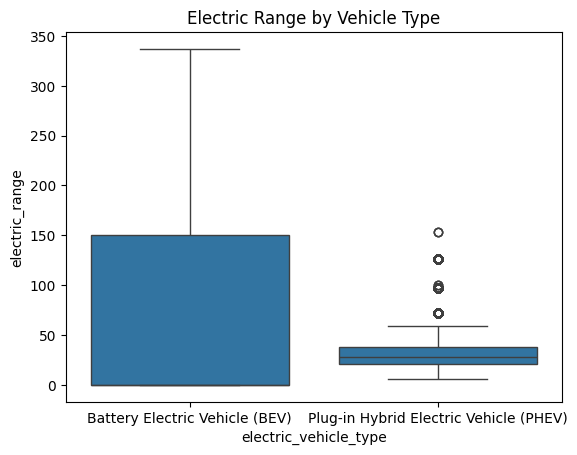

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='electric_vehicle_type', y='electric_range', data=ev_df)
plt.title("Electric Range by Vehicle Type")
plt.show()


The supporting boxplot of `electric_range` by vehicle type reveals that:

- **PHEVs cluster tightly under 50 miles of range**, while
- **BEVs typically range from 100 to 300+ miles**

This creates a **clear and natural separation** between the two classes, making it straightforward for the classifier to distinguish between them. In this case, the model is not overfitting or memorizing, but it's simply learning a strong signal present in the data.

Therefore, the high accuracy is a result of **well-separated feature distributions**, not data leakage or overfitting.

### Save the model

In [ ]:
import joblib

# saving the logistic regression pipeline
joblib.dump(model_pipeline, 'logistic_model.pkl')